<a href="https://colab.research.google.com/github/JoseAugustoV/ATIVIDADE-1---API-1-2026-/blob/main/Regress%C3%A3o_Linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("athiramolps/ice-cream-sales-and-temperature")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ice-cream-sales-and-temperature' dataset.
Path to dataset files: /kaggle/input/ice-cream-sales-and-temperature


In [8]:
import pandas as pd

In [9]:
import os

# List files in the downloaded directory to find the CSV file
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if csv_files:
    csv_file_path = os.path.join(path, csv_files[0])
    df_ice_cream = pd.read_csv(csv_file_path)
    print(f"Successfully loaded '{csv_files[0]}' into DataFrame.\n")
    display(df_ice_cream.head())
else:
    print("No CSV files found in the downloaded directory.")

Successfully loaded 'Ice Cream Sales and Temperature.csv' into DataFrame.



,Date,Time,Temperature (Celsius),Ice Cream Sales
0,2023-01-01,08:00,18,20
1,2023-01-01,08:05,19,22
2,2023-01-01,08:10,20,25
3,2023-01-01,08:15,21,24
4,2023-01-01,08:20,22,26


Mean Squared Error: 16.94
R-squared: 0.88
Model Coefficients (Slope): -0.67
Model Intercept: 46.50


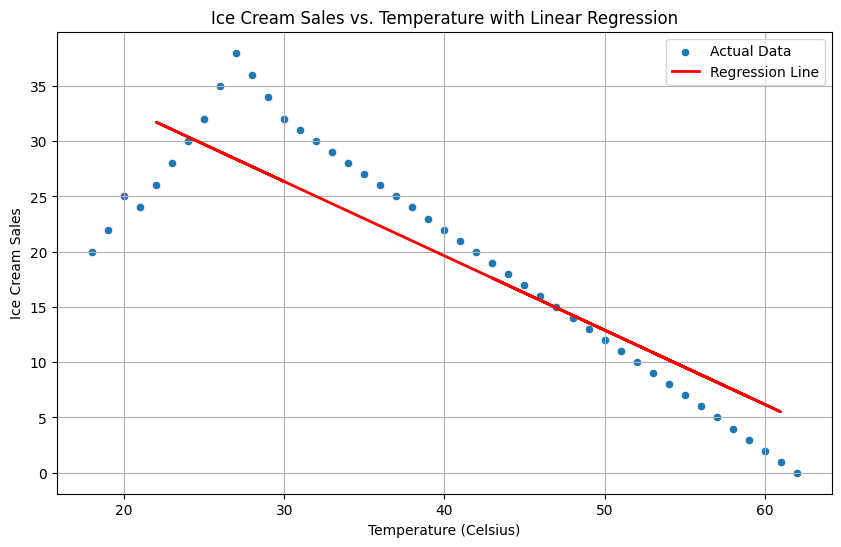

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Define features (X) and target (y)
X = df_ice_cream[['Temperature (Celsius)']]
y = df_ice_cream['Ice Cream Sales']

# Split the data into training and testing sets (optional, but good practice)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")
print(f"Model Coefficients (Slope): {model.coef_[0]:.2f}")
print(f"Model Intercept: {model.intercept_:.2f}")

# Visualize the regression line
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature (Celsius)', y='Ice Cream Sales', data=df_ice_cream, label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Ice Cream Sales vs. Temperature with Linear Regression')
plt.xlabel('Temperature (Celsius)')
plt.ylabel('Ice Cream Sales')
plt.legend()
plt.grid(True)
plt.show()